# Fraud detection in Blockchain transactions

In [196]:
#importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

#### Load dataset

In [197]:
data = pd.read_csv(r"transaction_dataset.csv")

In [198]:
data.head(10)

,Unnamed: 0,Index,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,Unique Received From Addresses,Unique Sent To Addresses,min value received,max value received,avg val received,min val sent,max val sent,avg val sent,min value sent to contract,max val sent to contract,avg value sent to contract,total transactions (including tnx to create contract,total Ether sent,total ether received,total ether sent contracts,total ether balance,Total ERC20 tnxs,ERC20 total Ether received,ERC20 total ether sent,ERC20 total Ether sent contract,ERC20 uniq sent addr,ERC20 uniq rec addr,ERC20 uniq sent addr.1,ERC20 uniq rec contract addr,ERC20 avg time between sent tnx,ERC20 avg time between rec tnx,ERC20 avg time between rec 2 tnx,ERC20 avg time between contract tnx,ERC20 min val rec,ERC20 max val rec,ERC20 avg val rec,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,40,118,0.000000,45.806785,6.589513,0.000000,31.220000,1.200681,0.0,0.0,0.0,810,865.691093,586.466675,0.0,-279.224419,265.0,3.558854e+07,3.560317e+07,0.0,30.0,54.0,0.0,58.0,0.0,0.0,0.0,0.0,0.0,1.500000e+07,265586.147600,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,5,14,0.000000,2.613269,0.385685,0.000000,1.800000,0.032844,0.0,0.0,0.0,102,3.087297,3.085478,0.0,-0.001819,8.0,4.034283e+02,2.260809e+00,0.0,1.0,5.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,3.650000e+02,57.632615,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,10,2,0.113119,1.165453,0.358906,0.050000,3.538616,1.794308,0.0,0.0,0.0,12,3.588616,3.589057,0.0,0.000441,8.0,5.215121e+02,0.000000e+00,0.0,0.0,7.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,4.428198e+02,65.189009,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,3,4,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,7,13,0.000000,500.000000,99.488840,0.000000,450.000000,70.001834,0.0,0.0,0.0,34,1750.045862,895.399559,0.0,-854.646303,14.0,1.711105e+04,1.141223e+04,0.0,2.0,11.0,0.0,11.0,0.0,0.0,0.0,0.0,0.0,1.141223e+04,1555.550174,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,4,5,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,7,19,0.000000,12.802411,2.671095,0.000000,9.000000,0.022688,0.0,0.0,0.0,4619,104.318883,53.421897,0.0,-50.896986,42.0,1.628297e+05,1.235399e+05,0.0,4.0,23.0,0.0,27.0,0.0,0.0,0.0,0.0,0.0,9.000000e+04,4934.232147,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS
5,5,6,0x000895ad78f4403ecd9468900e68d6ee506136fd,0,9900.12,375.48,20926.68,2,3,0,2,1,0.724148,4.813776,3.234908,4.166800,5.536916,4.851858,0.0,0.0,0.0,5,9.703716,9.704724,0.0,0.001008,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0,0,0
6,6,7,0x000d63fc5df52b0204374c2f5a3249779805d5d1,0,69.46,629.44,8660.35,25,11,0,9,20,0.049000,2.650000,1.098115,0.009457,4.284785,0.482496,0.0,0.0,0.0,36,12.062394,12.079266,0.0,0.016872,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0,0,0
7,7,8,0x000e001ab444fa8d6dc4a402f8d7cfc88fe8c64d,0,1497.39,176.84,319828.05,213,5,0,3,3,0.118490,2.000000,0.891098,0.000000,0.700000,0.040861,0.0,0.0,0.0,218,8.703392,4.455490,0.0,-4.247902,7.0,3.979520e+02,0.000000e+00,0.0,0.0,5.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,3.650000e+02,56.850281,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,

In [199]:
data.shape #(rows,cols)

(9841, 51)

In [200]:
data.columns

Index(['Unnamed: 0', 'Index', 'Address', 'FLAG', 'Avg min between sent tnx',
       'Avg min between received tnx',
       'Time Diff between first and last (Mins)', 'Sent tnx', 'Received Tnx',
       'Number of Created Contracts', 'Unique Received From Addresses',
       'Unique Sent To Addresses', 'min value received', 'max value received ',
       'avg val received', 'min val sent', 'max val sent', 'avg val sent',
       'min value sent to contract', 'max val sent to contract',
       'avg value sent to contract',
       'total transactions (including tnx to create contract',
       'total Ether sent', 'total ether received',
       'total ether sent contracts', 'total ether balance',
       ' Total ERC20 tnxs', ' ERC20 total Ether received',
       ' ERC20 total ether sent', ' ERC20 total Ether sent contract',
       ' ERC20 uniq sent addr', ' ERC20 uniq rec addr',
       ' ERC20 uniq sent addr.1', ' ERC20 uniq rec contract addr',
       ' ERC20 avg time between sent tnx', ' ERC20 

In [201]:
data=data.drop(columns='Unnamed: 0')

#### Dropping columns with only one value

In [202]:
cols=[]
for col in data.columns:
    if data[col].nunique()==1:
        print(col,":",data[col].unique())
        cols.append(col)
data=data.drop(columns=cols)

 ERC20 avg time between sent tnx : [ 0. nan]
 ERC20 avg time between rec tnx : [ 0. nan]
 ERC20 avg time between rec 2 tnx : [ 0. nan]
 ERC20 avg time between contract tnx : [ 0. nan]
 ERC20 min val sent contract : [ 0. nan]
 ERC20 max val sent contract : [ 0. nan]
 ERC20 avg val sent contract : [ 0. nan]


#### Basic cleaning

In [203]:
data.columns = data.columns.str.replace(' ', '_')
data.drop_duplicates(inplace=True)

#### Labeling categorical columns

In [204]:
categorical_cols = data.select_dtypes('O').columns
data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)
# data.drop(columns=categorical_cols, inplace=True)

#### Remove high zero-percentage features

In [205]:
zero_values = {}
for col in data.columns:
    zero_values[col] = (data[col] == 0).sum() / len(data) * 100

In [206]:
drop_zero_features = [col for col in zero_values if zero_values[col] > 90 and col != 'FLAG']
data.drop(columns=drop_zero_features, inplace=True)

#### Handle missing values

In [207]:
data.fillna(data.mean(), inplace=True)

### Final dataset

In [208]:
data.head(10)

,Index,FLAG,Avg_min_between_sent_tnx,Avg_min_between_received_tnx,Time_Diff_between_first_and_last_(Mins),Sent_tnx,Received_Tnx,Number_of_Created_Contracts,Unique_Received_From_Addresses,Unique_Sent_To_Addresses,min_value_received,max_value_received_,avg_val_received,min_val_sent,max_val_sent,avg_val_sent,total_transactions_(including_tnx_to_create_contract,total_Ether_sent,total_ether_received,total_ether_balance,_Total_ERC20_tnxs,_ERC20_total_Ether_received,_ERC20_total_ether_sent,_ERC20_uniq_sent_addr,_ERC20_uniq_rec_addr,_ERC20_uniq_rec_contract_addr,_ERC20_min_val_rec,_ERC20_max_val_rec,_ERC20_avg_val_rec,_ERC20_min_val_sent,_ERC20_max_val_sent,_ERC20_avg_val_sent,_ERC20_uniq_sent_token_name,_ERC20_uniq_rec_token_name,_ERC20_most_sent_token_type_,_ERC20_most_sent_token_type_0,_ERC20_most_rec_token_type_0
0,1,0,844.26,1093.71,704785.63,721,89,0,40,118,0.000000,45.806785,6.589513,0.000000,31.220000,1.200681,810,865.691093,586.466675,-279.224419,265.0,3.558854e+07,3.560317e+07,30.0,54.0,58.0,0.0,1.500000e+07,265586.147600,0.000000,1.683100e+07,271779.920000,39.0,57.0,False,False,False
1,2,0,12709.07,2958.44,1218216.73,94,8,0,5,14,0.000000,2.613269,0.385685,0.000000,1.800000,0.032844,102,3.087297,3.085478,-0.001819,8.0,4.034283e+02,2.260809e+00,1.0,5.0,7.0,0.0,3.650000e+02,57.632615,2.260809,2.260809e+00,2.260809,1.0,7.0,False,False,False
2,3,0,246194.54,2434.02,516729.30,2,10,0,10,2,0.113119,1.165453,0.358906,0.050000,3.538616,1.794308,12,3.588616,3.589057,0.000441,8.0,5.215121e+02,0.000000e+00,0.0,7.0,8.0,0.0,4.428198e+02,65.189009,0.000000,0.000000e+00,0.000000,0.0,8.0,False,False,False
3,4,0,10219.60,15785.09,397555.90,25,9,0,7,13,0.000000,500.000000,99.488840,0.000000,450.000000,70.001834,34,1750.045862,895.399559,-854.646303,14.0,1.711105e+04,1.141223e+04,2.0,11.0,11.0,0.0,1.141223e+04,1555.550174,100.000000,9.029231e+03,3804.076893,1.0,11.0,False,False,False
4,5,0,36.61,10707.77,382472.42,4598,20,1,7,19,0.000000,12.802411,2.671095,0.000000,9.000000,0.022688,4619,104.318883,53.421897,-50.896986,42.0,1.628297e+05,1.235399e+05,4.0,23.0,27.0,0.0,9.000000e+04,4934.232147,0.000000,4.500000e+04,13726.659220,6.0,27.0,False,False,False
5,6,0,9900.12,375.48,20926.68,2,3,0,2,1,0.724148,4.813776,3.234908,4.166800,5.536916,4.851858,5,9.703716,9.704724,0.001008,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.0,0.0,False,True,True
6,7,0,69.46,629.44,8660.35,25,11,0,9,20,0.049000,2.650000,1.098115,0.009457,4.284785,0.482496,36,12.062394,12.079266,0.016872,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.0,0.0,False,True,True
7,8,0,1497.39,176.84,319828.05,213,5,0,3,3,0.118490,2.000000,0.891098,0.000000,0.700000,0.040861,218,8.703392,4.455490,-4.247902,7.0,3.979520e+02,0.000000e+00,0.0,5.0,7.0,0.0,3.650000e+02,56.850281,0.000000,0.000000e+00,0.000000,0.0,7.0,False,False,False
8,9,0,0.00,0.00,496.62,1,1,0,1,1,2.000000,2.000000,2.000000,1.999380,1.999380,1.999380,2,1.999380,2.000000,0.000620,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.0,0.0,False,True,True
9,10,0,2570.59,3336.01,30572.70,8,3,0,2,4,0.100000,40.000000,16.700000,0.100000,40.000000,18.634625,11,149.077000,50.100000,-98.977000,1.0,6.000000e+02,0.000000e+00,0.0,1.0,1.0,600.0,6.000000e+02,600.000000,0.000000,0.000000e+00,0.000000,0.0,1.0,False,False,False


In [209]:
data.shape

(9841, 37)

#### Split features and target

In [210]:
X = data.drop(columns='FLAG')
y = data['FLAG']

#### Train-test split

In [211]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

#### Handle imbalanced data

In [212]:
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

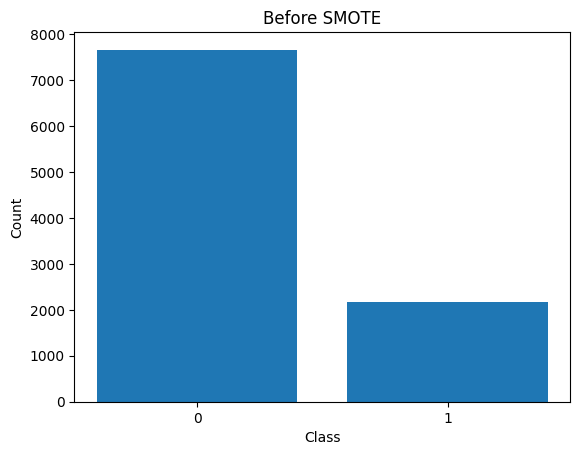

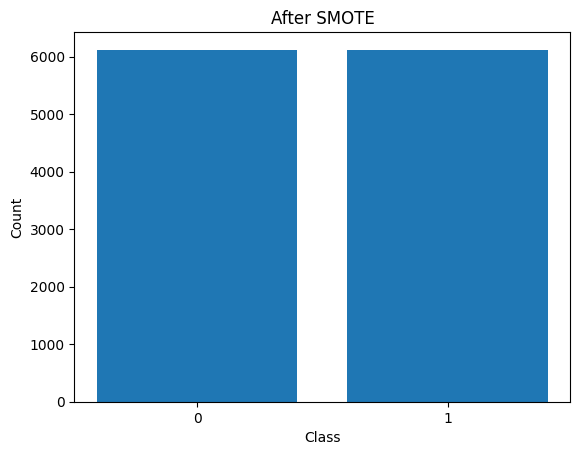

In [213]:
# Before SMOTE
before_counts = y.value_counts()

plt.figure()
plt.bar(before_counts.index.astype(str), before_counts.values)
plt.title("Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# After SMOTE
after_counts = pd.Series(y_train).value_counts()

plt.figure()
plt.bar(after_counts.index.astype(str), after_counts.values)
plt.title("After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

#### Feature scaling

In [214]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### Define models

In [215]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC()
}

#### Train & evaluate

In [216]:
results = []

for name, model in models.items():
    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })
    print(f'{name} training completed')


Training Logistic Regression...
Logistic Regression training completed

Training Decision Tree...
Decision Tree training completed

Training Random Forest...
Random Forest training completed

Training SVM...
SVM training completed


#### Results

In [217]:
results_df = pd.DataFrame(results)
print("\nFinal Results:\n")
results_df.head()


Final Results:



,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.961910,0.860656,0.983607,0.918033
1,Decision Tree,0.985272,0.962791,0.969555,0.966161
2,Random Forest,0.994921,1.000000,0.976581,0.988152
3,SVM,0.969528,0.894624,0.974239,0.932735


#### Finding the best model

In [218]:
results_df = results_df.sort_values(by="F1 Score", ascending=False)
best_model = results_df.iloc[0]
print("Best Model:", best_model["Model"])

Best Model: Random Forest
